<a href="https://colab.research.google.com/github/rogon666/UMSA/blob/main/UMSA_2026_002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Primeras filas de la base simulada:
       ingreso  edad  mujer    sexo
0  3597.096520    24      0  Hombre
1  4920.347684    50      0  Hombre
2  5039.771507    56      1   Mujer
3  4370.632028    60      1   Mujer
4  4047.525861    39      0  Hombre

Resumen descriptivo general:
           ingreso         edad        mujer
count  2000.000000  2000.000000  2000.000000
mean   4173.236152    43.436000     0.502000
std    1197.627033    12.563193     0.500121
min     849.399850    22.000000     0.000000
25%    3304.142562    33.000000     0.000000
50%    4192.949322    43.500000     1.000000
75%    5060.642778    54.000000     1.000000
max    7611.997830    65.000000     1.000000

Resumen de ingresos por sexo:
               mean       median          std          min          max
sexo                                                                   
Hombre  4486.246721  4543.736877  1156.937421  1644.552194  7611.997830
Mujer   3862.719691  3893.772147  1156.276024   849.399850  6900.

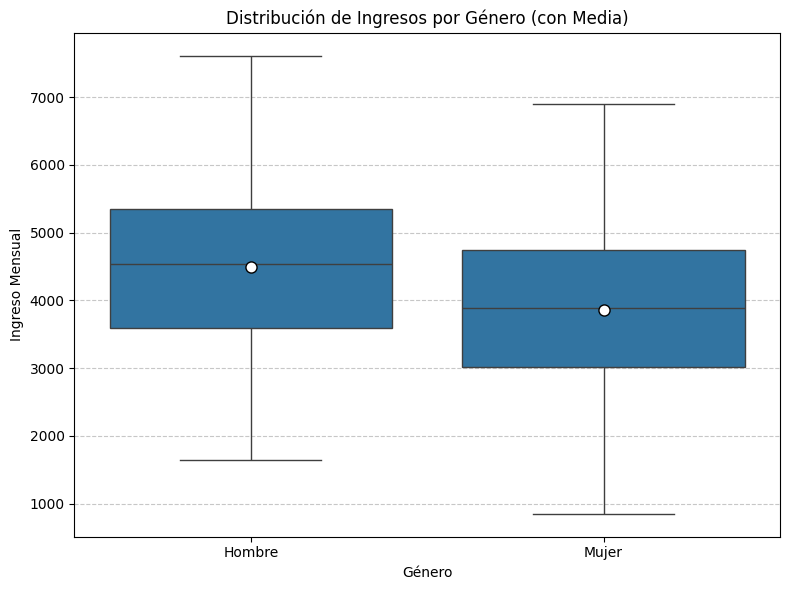

In [3]:
# ==========================================================
# Maestría en Ciencia y Análisis de Datos
# Universidad Mayor de San Andrés
# ----------------------------------------------------------
#    Modelos lineales y modelos lineales generalizados
# ----------------------------------------------------------
#        Rolando Gonzales Martinez, Julio 2026
# ==========================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Simulación de datos
# ------------------------------------------------------------

np.random.seed(123)

n = 2000

# Edad entre 22 y 65 años
edad = np.random.randint(22, 66, size=n)

# Sexo: 0 = hombre, 1 = mujer
mujer = np.random.binomial(1, 0.5, size=n)

# Variable categórica para gráficos y tablas
sexo = np.where(mujer == 1, "Mujer", "Hombre")

# ------------------------------------------------------------
# Modelo generador de datos en niveles
# ------------------------------------------------------------
#
# ingreso_i = beta0 + beta_edad * edad_i + beta_mujer * mujer_i + u_i
#
# mujer_i = 1 si la persona es mujer
# mujer_i = 0 si la persona es hombre
#
# beta_mujer < 0 implica que, manteniendo constante la edad,
# las mujeres tienen menor ingreso promedio que los hombres.

# Parámetros reales poblacionales
beta0 = 1000          # ingreso base teórico
beta_edad = 80        # incremento promedio del ingreso por año adicional de edad
beta_mujer = -600     # penalización salarial promedio para mujeres
sigma = 600           # dispersión no observada del ingreso

# Error aleatorio
error = np.random.normal(0, sigma, size=n)

# Ingreso simulado en niveles monetarios
ingreso = beta0 + beta_edad * edad + beta_mujer * mujer + error

# Base de datos
df = pd.DataFrame({
    "ingreso": ingreso,
    "edad": edad,
    "mujer": mujer,
    "sexo": sexo
})

# ------------------------------------------------------------
# 2. Estadística descriptiva
# ------------------------------------------------------------

print("\nPrimeras filas de la base simulada:")
print(df.head())

print("\nResumen descriptivo general:")
print(df[["ingreso", "edad", "mujer"]].describe())

print("\nResumen de ingresos por sexo:")
resumen_sexo = df.groupby("sexo")["ingreso"].agg(["mean", "median", "std", "min", "max"])
print(resumen_sexo)

import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='sexo', y='ingreso', data=df, showmeans=True,
            meanprops={'marker':'o', 'markerfacecolor':'white', 'markeredgecolor':'black',
                       'markersize':'8'})
plt.title('Distribución de Ingresos por Género (con Media)')
plt.xlabel('Género')
plt.ylabel('Ingreso Mensual')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Regresión lineal simple**


REGRESIÓN LINEAL SIMPLE: ingreso ~ edad
                            OLS Regression Results                            
Dep. Variable:                ingreso   R-squared:                       0.679
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                     4229.
Date:                Thu, 09 Jul 2026   Prob (F-statistic):               0.00
Time:                        13:10:38   Log-Likelihood:                -15877.
No. Observations:                2000   AIC:                         3.176e+04
Df Residuals:                    1998   BIC:                         3.177e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

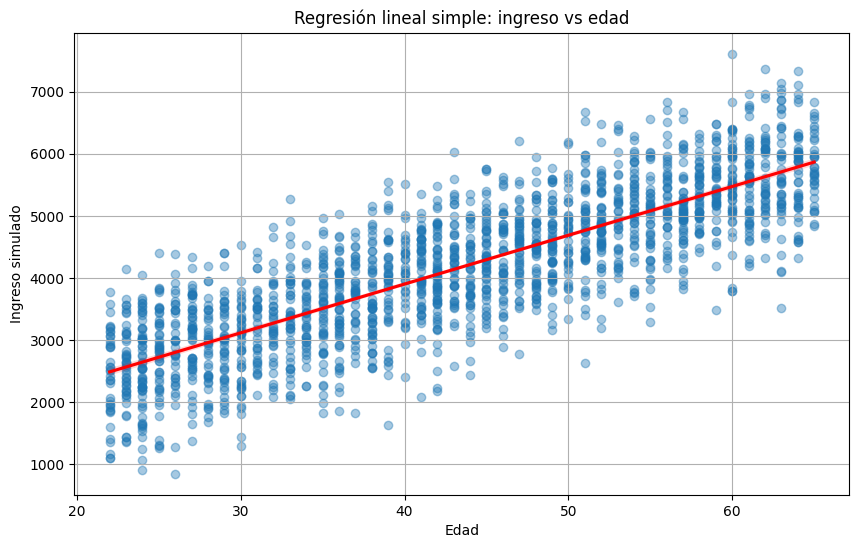

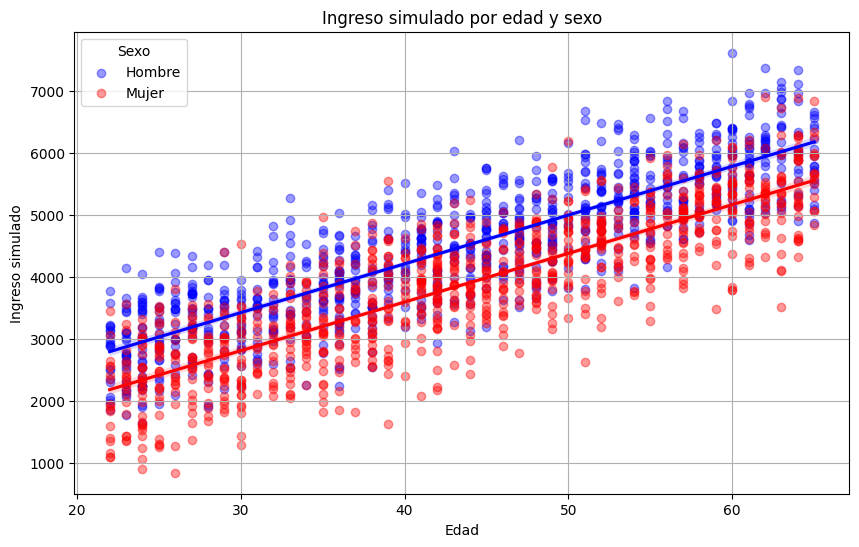

In [5]:
# ------------------------------------------------------------
# 3. Regresión lineal simple: ingreso vs edad
# ------------------------------------------------------------

# Modelo:
# ingreso_i = alpha0 + alpha1 * edad_i + e_i

X_simple = df[["edad"]]
X_simple = sm.add_constant(X_simple)

y = df["ingreso"]

modelo_simple = sm.OLS(y, X_simple).fit()

print("\n============================================================")
print("REGRESIÓN LINEAL SIMPLE: ingreso ~ edad")
print("============================================================")
print(modelo_simple.summary())

# Coeficientes del modelo simple
alpha0_hat = modelo_simple.params["const"]
alpha1_hat = modelo_simple.params["edad"]

print("\nInterpretación del modelo simple:")
print(f"Intercepto estimado: {alpha0_hat:.2f}")
print(f"Coeficiente de edad: {alpha1_hat:.2f}")

print(
    "\nEl coeficiente de edad indica que, en promedio, "
    f"un año adicional de edad se asocia con un aumento de {alpha1_hat:.2f} unidades monetarias "
    "en el ingreso."
)

print(
    "\nEl intercepto representa el ingreso predicho cuando edad = 0. "
    "Como la muestra solo incluye edades entre 22 y 65 años, este valor es principalmente "
    "un parámetro técnico de ajuste de la recta, no una predicción sustantivamente interpretable."
)


# ------------------------------------------------------------
# 7. Gráfico: regresión lineal simple
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="edad",
    y="ingreso",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)

plt.xlabel("Edad")
plt.ylabel("Ingreso simulado")
plt.title("Regresión lineal simple: ingreso vs edad")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 8. Gráfico: ingreso por edad y sexo
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df[df["sexo"] == "Hombre"],
    x="edad",
    y="ingreso",
    scatter_kws={"alpha": 0.4},
    label="Hombre",
    color="blue"
)

sns.regplot(
    data=df[df["sexo"] == "Mujer"],
    x="edad",
    y="ingreso",
    scatter_kws={"alpha": 0.4},
    label="Mujer",
    color="red"
)

plt.xlabel("Edad")
plt.ylabel("Ingreso simulado")
plt.title("Ingreso simulado por edad y sexo")
plt.legend(title="Sexo")
plt.grid(True)
plt.show()


**Regresión lineal múltiple**

In [6]:
# ------------------------------------------------------------
# 4. Regresión lineal múltiple: ingreso vs edad y sexo
# ------------------------------------------------------------

# Modelo:
# ingreso_i = beta0 + beta1 * edad_i + beta2 * mujer_i + u_i

X_multiple = df[["edad", "mujer"]]
X_multiple = sm.add_constant(X_multiple)

modelo_multiple = sm.OLS(y, X_multiple).fit()

print("\n============================================================")
print("REGRESIÓN LINEAL MÚLTIPLE: ingreso ~ edad + mujer")
print("============================================================")
print(modelo_multiple.summary())

# Coeficientes del modelo múltiple
beta0_hat = modelo_multiple.params["const"]
beta_edad_hat = modelo_multiple.params["edad"]
beta_mujer_hat = modelo_multiple.params["mujer"]

print("\nInterpretación del modelo múltiple:")
print(f"Intercepto estimado: {beta0_hat:.2f}")
print(f"Coeficiente de edad: {beta_edad_hat:.2f}")
print(f"Coeficiente de mujer: {beta_mujer_hat:.2f}")

print(
    "\nEl coeficiente de edad indica que, manteniendo constante el sexo, "
    f"un año adicional de edad incrementa el ingreso esperado en {beta_edad_hat:.2f} unidades monetarias."
)

print(
    "\nEl coeficiente de mujer mide la diferencia promedio de ingreso entre mujeres y hombres "
    "con la misma edad. Como la variable mujer toma el valor 1 para mujeres y 0 para hombres, "
    f"el coeficiente estimado de {beta_mujer_hat:.2f} implica que, condicional en la edad, "
    f"las mujeres ganan en promedio {abs(beta_mujer_hat):.2f} unidades monetarias menos que los hombres."
)

print(
    "\nEl intercepto corresponde al ingreso predicho para un hombre con edad igual a cero. "
    "Dado que edad = 0 está fuera del rango observado, el intercepto debe entenderse como "
    "un parámetro necesario para ubicar la recta de regresión, no como una predicción realista."
)

# ------------------------------------------------------------
# 5. Comparación de coeficientes: modelo simple vs múltiple
# ------------------------------------------------------------

comparacion = pd.DataFrame({
    "Modelo simple": modelo_simple.params,
    "Modelo múltiple": modelo_multiple.params
})

print("\nComparación de coeficientes:")
print(comparacion)

print(
    "\nLa diferencia entre el coeficiente de edad del modelo simple y el coeficiente de edad "
    "del modelo múltiple muestra cómo cambia la asociación edad-ingreso cuando se controla por sexo. "
    "El modelo múltiple es más informativo porque separa el efecto parcial de la edad de la diferencia "
    "promedio de ingresos entre hombres y mujeres."
)


REGRESIÓN LINEAL MÚLTIPLE: ingreso ~ edad + mujer
                            OLS Regression Results                            
Dep. Variable:                ingreso   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     2919.
Date:                Thu, 09 Jul 2026   Prob (F-statistic):               0.00
Time:                        13:16:55   Log-Likelihood:                -15647.
No. Observations:                2000   AIC:                         3.130e+04
Df Residuals:                    1997   BIC:                         3.132e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c